# Лабораторна Робота №8
## Тема: Структури даних дерево, купа, гештаблиця
### Мета: засвоїти основні функції та алгоритми роботи з деревами та купою засобами Python.
#### Виконав: Гнатюк Євгеній

# Порядок виконання роботи
## Завдання 1:

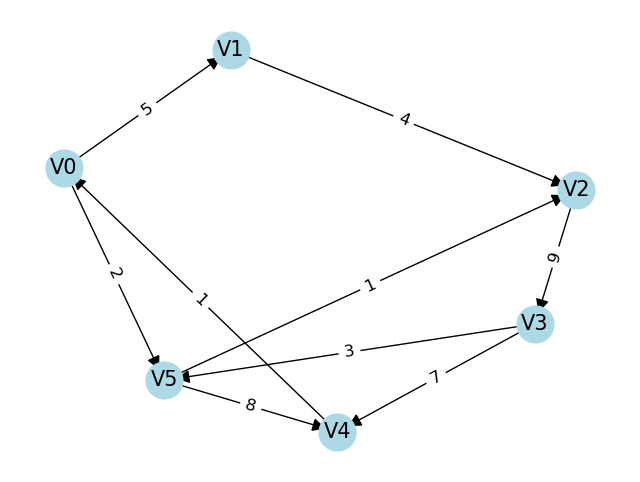

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.DiGraph()
edges = [
    ('V0', 'V1', 5), ('V0', 'V5', 2), 
    ('V1', 'V2', 4), 
    ('V2', 'V3', 9), 
    ('V3', 'V4', 7), ('V3', 'V5', 3), 
    ('V4', 'V0', 1), 
    ('V5', 'V4', 8), ('V5', 'V2', 1)
]
G.add_weighted_edges_from(edges)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=15, font_family='sans-serif')
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), arrows=True, arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)
plt.axis('off')
plt.show()

 # Завдання 2:

In [3]:
start_node = 'V0'

print(f"Найкоротші шляхи від вершини {start_node}")
length_d, path_d = nx.single_source_dijkstra(G, start_node)
print("\nАлгоритм Дейкстри:")
for target in length_d:
    print(f"До {target}: відстань = {length_d[target]}, шлях = {path_d[target]}")

length_bf, path_bf = nx.single_source_bellman_ford(G, start_node)
print("\nАлгоритм Беллмана-Форда:")
for target in length_bf:
    print(f"До {target}: відстань = {length_bf[target]}, шлях = {path_bf[target]}")

Найкоротші шляхи від вершини V0

Алгоритм Дейкстри:
До V0: відстань = 0, шлях = ['V0']
До V5: відстань = 2, шлях = ['V0', 'V5']
До V2: відстань = 3, шлях = ['V0', 'V5', 'V2']
До V1: відстань = 5, шлях = ['V0', 'V1']
До V4: відстань = 10, шлях = ['V0', 'V5', 'V4']
До V3: відстань = 12, шлях = ['V0', 'V5', 'V2', 'V3']

Алгоритм Беллмана-Форда:
До V0: відстань = 0, шлях = ['V0']
До V1: відстань = 5, шлях = ['V0', 'V1']
До V5: відстань = 2, шлях = ['V0', 'V5']
До V2: відстань = 3, шлях = ['V0', 'V5', 'V2']
До V4: відстань = 10, шлях = ['V0', 'V5', 'V4']
До V3: відстань = 12, шлях = ['V0', 'V5', 'V2', 'V3']


# Завдання 3:

In [5]:
adj_dict = {node: list(G.successors(node)) for node in G.nodes()}

def dfs_paths(graph_dict, start, goal, path=None):
    if path is None:
        path = [start]
    if start == goal:
        yield path
    for next_node in set(graph_dict[start]) - set(path):
        yield from dfs_paths(graph_dict, next_node, goal, path + [next_node])

def bfs_paths(graph_dict, start, goal):
    queue = [(start, [start])]
    while queue:
        vertex, path = queue.pop(0)
        for next_node in set(graph_dict[vertex]) - set(path):
            if next_node == goal:
                yield path + [next_node]
            else:
                queue.append((next_node, path + [next_node]))

start_v, goal_v = 'V0', 'V4'

print(f"\n--- Всі шляхи від {start_v} до {goal_v} ---")
print("DFS шляхи:", list(dfs_paths(adj_dict, start_v, goal_v)))
print("BFS шляхи:", list(bfs_paths(adj_dict, start_v, goal_v)))


--- Всі шляхи від V0 до V4 ---
DFS шляхи: [['V0', 'V5', 'V2', 'V3', 'V4'], ['V0', 'V5', 'V4'], ['V0', 'V1', 'V2', 'V3', 'V5', 'V4'], ['V0', 'V1', 'V2', 'V3', 'V4']]
BFS шляхи: [['V0', 'V5', 'V4'], ['V0', 'V5', 'V2', 'V3', 'V4'], ['V0', 'V1', 'V2', 'V3', 'V4'], ['V0', 'V1', 'V2', 'V3', 'V5', 'V4']]


# Контрольні запитання: